In [102]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tqdm import tqdm
import time




In [103]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [104]:
X_train=torch.from_numpy(X_train).float()
X_test=torch.from_numpy(X_test).float()
X_train=X_train.unsqueeze(1)
X_test=X_test.unsqueeze(1)
y_train=torch.from_numpy(y_train).long()
y_test=torch.from_numpy(y_test).long()
print(X_train.shape,y_train.shape)
print(X_train.shape[0])

torch.Size([60000, 1, 28, 28]) torch.Size([60000])
60000


In [105]:
class CNN_network(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=torch.nn.Conv2d(1,16,3)
        self.pool=torch.nn.MaxPool2d(2,2)
        self.relu=torch.nn.ReLU()
        self.flatten=torch.nn.Flatten()
        self.linear=torch.nn.Linear(16*13*13,10)
    def forward(self,x):
        x=self.conv1(x)
        x=self.relu(x)
        x=self.pool(x)
        x=self.flatten(x)
        x=self.linear(x)
        return x
        

In [106]:
model=CNN_network()
batch_size=64
epochs=10
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)
history=[]
loss_fn=torch.nn.CrossEntropyLoss()
start = time.time()
for epoch in tqdm(range(epochs)):
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[ i : i + batch_size ]
        Y_batch = y_train[ i : i + batch_size ]
        optimizer.zero_grad()
        pred=model(X_batch)
        loss=loss_fn(pred,Y_batch)
        loss.backward()
        optimizer.step()
        history.append(loss.item())
end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

100%|██████████| 10/10 [00:28<00:00,  2.85s/it]

Training Time: 28.50 seconds


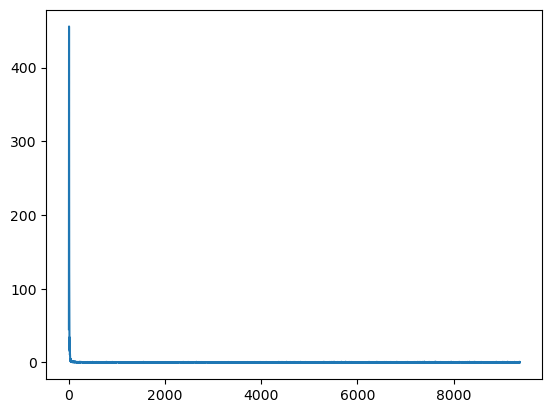

In [107]:
plt.plot(history)
plt.show()

In [108]:
model.eval()             #TRAIN SET ACCURACY

with torch.no_grad():
    logits = model(X_train)       #PREDIICTION
predictions = torch.argmax(logits, dim=1)
correct = (predictions == y_train).sum().item()
accuracy = correct / len(y_train)
print(predictions,y_train)
print(f"Accuracy: {accuracy * 100:.2f}%")

tensor([5, 0, 4,  ..., 5, 6, 8]) tensor([5, 0, 4,  ..., 5, 6, 8])
Accuracy: 91.00%


In [109]:
model.eval()                #TEST SET ACCURACY

with torch.no_grad():
    logits = model(X_test)       #PREDIICTION
predictions = torch.argmax(logits, dim=1)
correct = (predictions == y_test).sum().item()
accuracy = correct / len(y_test)
print(predictions,y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

tensor([7, 2, 1,  ..., 4, 8, 6]) tensor([7, 2, 1,  ..., 4, 5, 6])
Accuracy: 90.74%
